## 0. Import libraries

In [ ]:
import os 
os.chdir('../..')

import numpy as np
import pandas as pd
import seaborn as sns
import tellurium as te
import re
import textwrap
import matplotlib.pyplot as plt
import itertools
import pickle

from mpl_toolkits.axes_grid1 import make_axes_locatable
from collections import defaultdict

from roadrunner import Config, Logger
Logger.disableLogging()
Config.setValue(Config.ROADRUNNER_DISABLE_PYTHON_DYNAMIC_PROPERTIES, True)
Config.setValue(Config.LOADSBMLOPTIONS_RECOMPILE, False) 
Config.setValue(Config.LLJIT_OPTIMIZATION_LEVEL, 4)
Config.setValue(Config.LLVM_SYMBOL_CACHE, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_GVN, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_CFG_SIMPLIFICATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_COMBINING, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_INST_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_CODE_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_SIMPLIFIER, True)
Config.setValue(Config.SIMULATEOPTIONS_COPY_RESULT, True)

In [ ]:
rfit = te.loada('iMC057.txt')

model_rxns = pd.read_csv('Reactions.csv')

In [ ]:
with open('filtering_parameter_sets/final_params.pkl', 'rb') as file:
    trainparams = pickle.load(file)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

In [ ]:
# Dilution factors we want to test
d_factors = [1/200, 1/100, 1/50, 1/10]
d_factors.reverse()

In [ ]:
pathway_dict = {
    'TCA Cycle': [
        'R1',   # 2-oxoglutarate dehydrogenase subunit E1
        'R7',   # Aconitate hydratase A
        'R8',   # Aconitate hydratase B
        'R20',  # Fumarate hydratase class I
        'R25',  # Malate dehydrogenase
        'R27',  # NADP-dependent isocitrate dehydrogenase
        'R28',  # NADP-dependent isocitrate dehydrogenase
        'R41',  # Succinate dehydrogenase
        'R42',  # Succinyl-CoA ligase
        'R46',  # Type II citrate synthase
        'R47'   # Isocitrate lyase
    ],

    'Glycolysis / Gluconeogenesis': [
        'R10',  # ATP-dependent 6-phosphofructokinase
        'R13',  # Enolase
        'R18',  # Fructose 1,6-bisphosphatase
        'R19',  # Fructose-bisphosphate aldolase
        'R21',  # Glucose-6-phosphate isomerase
        'R22',  # Glyceraldehyde-3-phosphate dehydrogenase
        'R23',  # Glycogen phosphorylase
        'R30',  # Phosphoenolpyruvate carboxykinase (ATP)
        'R32',  # Phosphoenolpyruvate synthase
        'R33',  # Phosphoglucomutase
        'R34',  # Phosphoglycerate kinase
        'R35',  # Phosphoglycerate mutase
        'R37',  # Pyruvate kinase I
        'R38',  # Pyruvate kinase II
        'R45'   # Triose-phosphate isomerase
    ],

    'Pentose Phosphate Pathway': [
        'R39',  # Ribose-5-phosphate isomerase
        'R40',  # Ribulose-phosphate 3-epimerase
        'R43',  # Transaldolase
        'R44',   # Transketolase
        'R54',  # Glucose-6-phosphate dehydrogenase
    ],

    'Fatty Acid Biosynthesis': [
        'R2',   # 3-oxoacyl-ACP reductase
        'R3',   # 3-oxoacyl-ACP synthase I
        'R4',   # 3-oxoacyl-ACP synthase III
        'R6',   # Acetyl-CoA carboxytransferase
        'R11',  # Beta-hydroxydecanoyl-ACP dehydratase
        'R12',  # Beta-ketoacyl-[acyl-carrier-protein] synthase II
        'R14',  # Enoyl-[acyl-carrier-protein] reductase
        'R24'   # Long-chain-fatty-acid--CoA ligase
        'R26'   # Malonyl CoA-ACP transacylase
    ],

    'Fatty Acid Degradation (β-Oxidation)': [
        'R5',   # Acetyl-CoA C-acyltransferase
        'R15',  # Fatty acid oxidation complex subunit alpha
        'R16',  # Fatty acid oxidation complex subunit alpha
        'R17'  # Fatty acid oxidation complex subunit alpha
        
    ],

    'Pyruvate Metabolism': [
        'R31',  # Phosphoenolpyruvate carboxylase
        'R36',  # Pyruvate dehydrogenase E1 component
        'R48',  # Acetyl-CoA synthetase
        'R50',  # Acetate kinase
        'R53'   # Lactate dehydrogenase
    ],

    'Glycine & Serine Metabolism': [
        'R49',  # Serine hydroxymethyltransferase
        'R52'  # L-serine ammonia-lyase
    ],

    'Energy & Nucleotide Metabolism + CO2/Bicarb Conversion': [
        'R9',   # Adenylate kinase
        'R29',  # Nucleoside-diphosphate kinase
        'R51' # Carbonic anhydrase
        
    ]
}

In [ ]:
rids = ['R56',
 'R57',
 'R58',
 'R59',
 'R60',
 'R61',
 'R64',
 'R69',
 'R70',
 'R71',
 'R83',
 'R90',
 'R123',
 'R157',
 'R169',
 'R171',
 'R172',
 'R173',
 'R174',
 'R175',
 'R176',
 'R177',
 'R181',
 'R204',
 'R245',
 'R255',
 'R256',
 'R257',
 'R268',
 'R270',
 'R271',
 'R272',
 'R273',
 'R299',
 'R300',
 'R304',
 'R305',
 'R307',
 'R308',
 'R346',
 'R347',
 'R351',
 'R371',
 'R372',
 'R373',
 'R406',
 'R197',
 'R269',
 'R345',
 'R62',
 'R63',
 'R227',
 'R228',
 'R219',
 'R224',
 'R225',
 'R258']

## Figure 5B: Malate production by various experimental conditions

In [ ]:
results_by_condition = defaultdict(list)

# --- assign parameters ---

param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["basePyruvate"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preOxaloacetate = rfit.getValue('Oxaloacetate')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["baseOxaloacetate"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)


rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["baseSerine"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preOxaloacetate = rfit.getValue('Oxaloacetate')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, 0, 0, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["mdh"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preOxaloacetate = rfit.getValue('Oxaloacetate')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, 0, p_hEC11719, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["mdhfdh"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preOxaloacetate = rfit.getValue('Oxaloacetate')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, p_hEC11719, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["fdh"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.001 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, 0]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["mdhfdhpyc"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.001 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.001 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


param_values['v73'] = 0
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
# param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

# Store formate vs. time
results_by_condition["fullpath"].append(results[:, [0, 1, 2, 3, 4, 5, 6, 7]])  # time + Malate

In [ ]:
maloxaneg = results_by_condition['baseOxaloacetate'][0][-1][4]
malpyrmdh = results_by_condition['mdh'][0][-1][4]
malpyrfdh = results_by_condition['fdh'][0][-1][4]
malpyrmdhfdh = results_by_condition['mdhfdh'][0][-1][4]
malpyr = results_by_condition['basePyruvate'][0][-1][4]
maloxamdhfdhpyc = results_by_condition['mdhfdhpyc'][0][-1][4]
malser = results_by_condition['baseSerine'][0][-1][4]
malserfull = results_by_condition['fullpath'][0][-1][4]

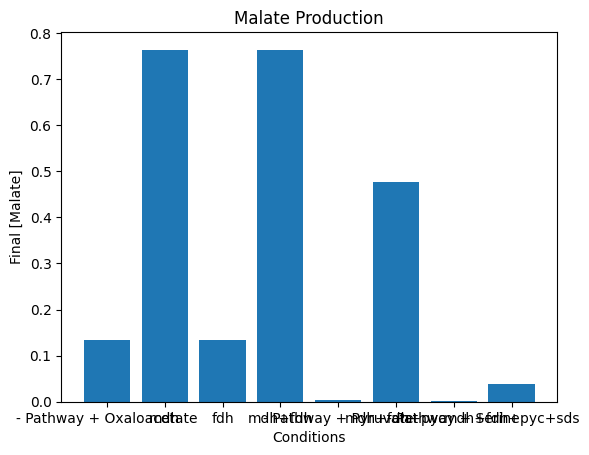

In [ ]:
# Sample data
categories = ['- Pathway + Oxaloacetate', 'mdh', 'fdh', 'mdh+fdh', '- Pathway + Pyruvate', 'mdh+fdh+pyc', '- Pathway + Serine', 'mdh+fdh+pyc+sds']
values = [maloxaneg, malpyrmdh, malpyrfdh, malpyrmdhfdh, malpyr, maloxamdhfdhpyc, malser, malserfull]

# Create the bar plot
plt.bar(categories, values)

# Add labels and title for clarity
plt.xlabel('Conditions') 
plt.ylabel('Final [Malate]')
plt.title('Malate Production')

plt.savefig('Figures/Figure_5B.svg')
# Display the plot
plt.show()

## Figure 5C: Enzyme titrations

In [ ]:
oaa_results = {}

param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for enzyme in ['fdh', 'mdh', 'pyc', 'sds']:
    for conc in [0, 0.001, 0.005]:
        if enzyme == 'fdh':
            hEC11719 = conc # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'mdh':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = conc # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'pyc':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = conc # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        else:
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = conc # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        # param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
        param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        oaa_results[f"{enzyme}_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

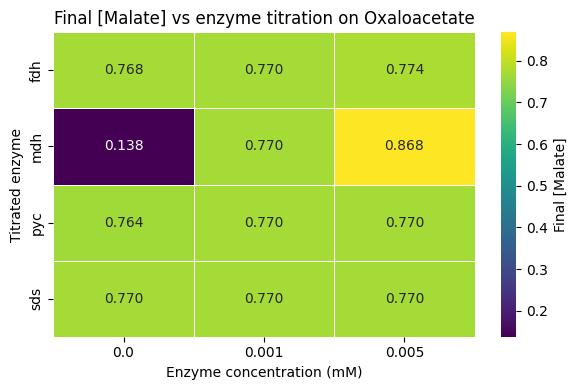

In [ ]:
# Extract final malate values into a matrix
enzymes = ['fdh', 'mdh', 'pyc', 'sds']
concs = [0, 0.001, 0.005]

# Create a DataFrame to hold the values
malate_df = pd.DataFrame(index=enzymes, columns=concs, dtype=float)

for key in oaa_results.keys():
    enzyme, conc = key.split('_')
    conc = float(conc)
    malate_df.loc[enzyme, conc] = oaa_results[key][-1][4]  # [4] is SMalate

# Sort columns numerically
malate_df = malate_df[sorted(malate_df.columns)]

# --- Plot ---
plt.figure(figsize=(6,4))
sns.heatmap(
    malate_df.astype(float),
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': 'Final [Malate]'},
    linewidths=0.5
)
plt.title("Final [Malate] vs enzyme titration on Oxaloacetate")
plt.xlabel("Enzyme concentration (mM)")
plt.ylabel("Titrated enzyme")
plt.tight_layout()
plt.show()


In [ ]:
pyr_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for enzyme in ['fdh', 'mdh', 'pyc', 'sds']:
    for conc in [0, 0.001, 0.005]:
        if enzyme == 'fdh':
            hEC11719 = conc # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'mdh':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = conc # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'pyc':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = conc # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        else:
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = conc # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        # param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
        # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        pyr_results[f"{enzyme}_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

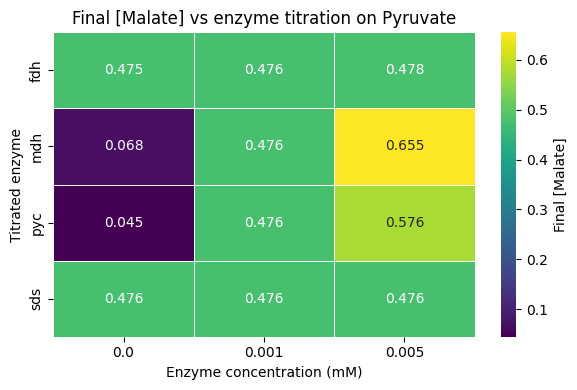

In [ ]:
# Extract final malate values into a matrix
enzymes = ['fdh', 'mdh', 'pyc', 'sds']
concs = [0, 0.001, 0.005]

# Create a DataFrame to hold the values
malate_df = pd.DataFrame(index=enzymes, columns=concs, dtype=float)

for key in pyr_results.keys():
    enzyme, conc = key.split('_')
    conc = float(conc)
    malate_df.loc[enzyme, conc] = pyr_results[key][-1][4]  # [4] is SMalate

# Sort columns numerically
malate_df = malate_df[sorted(malate_df.columns)]

# --- Plot ---
plt.figure(figsize=(6,4))
sns.heatmap(
    malate_df.astype(float),
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': 'Final [Malate]'},
    linewidths=0.5
)
plt.title("Final [Malate] vs enzyme titration on Pyruvate")
plt.xlabel("Enzyme concentration (mM)")
plt.ylabel("Titrated enzyme")
plt.tight_layout()
plt.show()


In [ ]:
ser_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for enzyme in ['fdh', 'mdh', 'pyc', 'sds']:
    for conc in [0, 0.001, 0.005]:
        if enzyme == 'fdh':
            hEC11719 = conc # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'mdh':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = conc # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        elif enzyme == 'pyc':
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = conc # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = 0.001 # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))
        else:
            hEC11719 = 0.001 # fdh
            p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

            eEC11137 = 0.001 # mdh
            p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

            hEC6411 = 0.001 # pyc
            p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

            hEC43117 = conc # sds
            p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
        # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        ser_results[f"{enzyme}_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

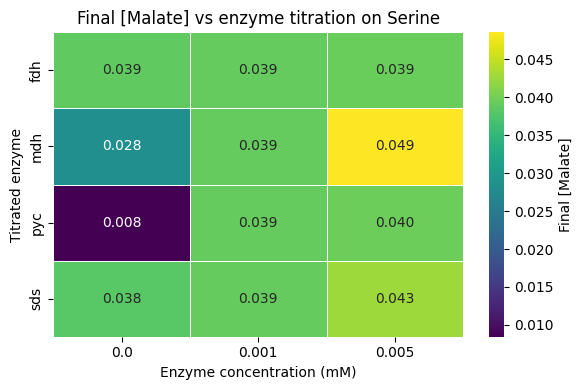

In [ ]:
# Extract final malate values into a matrix
enzymes = ['fdh', 'mdh', 'pyc', 'sds']
concs = [0, 0.001, 0.005]

# Create a DataFrame to hold the values
malate_df = pd.DataFrame(index=enzymes, columns=concs, dtype=float)

for key in ser_results.keys():
    enzyme, conc = key.split('_')
    conc = float(conc)
    malate_df.loc[enzyme, conc] = ser_results[key][-1][4]  # [4] is SMalate

# Sort columns numerically
malate_df = malate_df[sorted(malate_df.columns)]

# --- Plot ---
plt.figure(figsize=(6,4))
sns.heatmap(
    malate_df.astype(float),
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': 'Final [Malate]'},
    linewidths=0.5
)
plt.title("Final [Malate] vs enzyme titration on Serine")
plt.xlabel("Enzyme concentration (mM)")
plt.ylabel("Titrated enzyme")
plt.tight_layout()
plt.show()


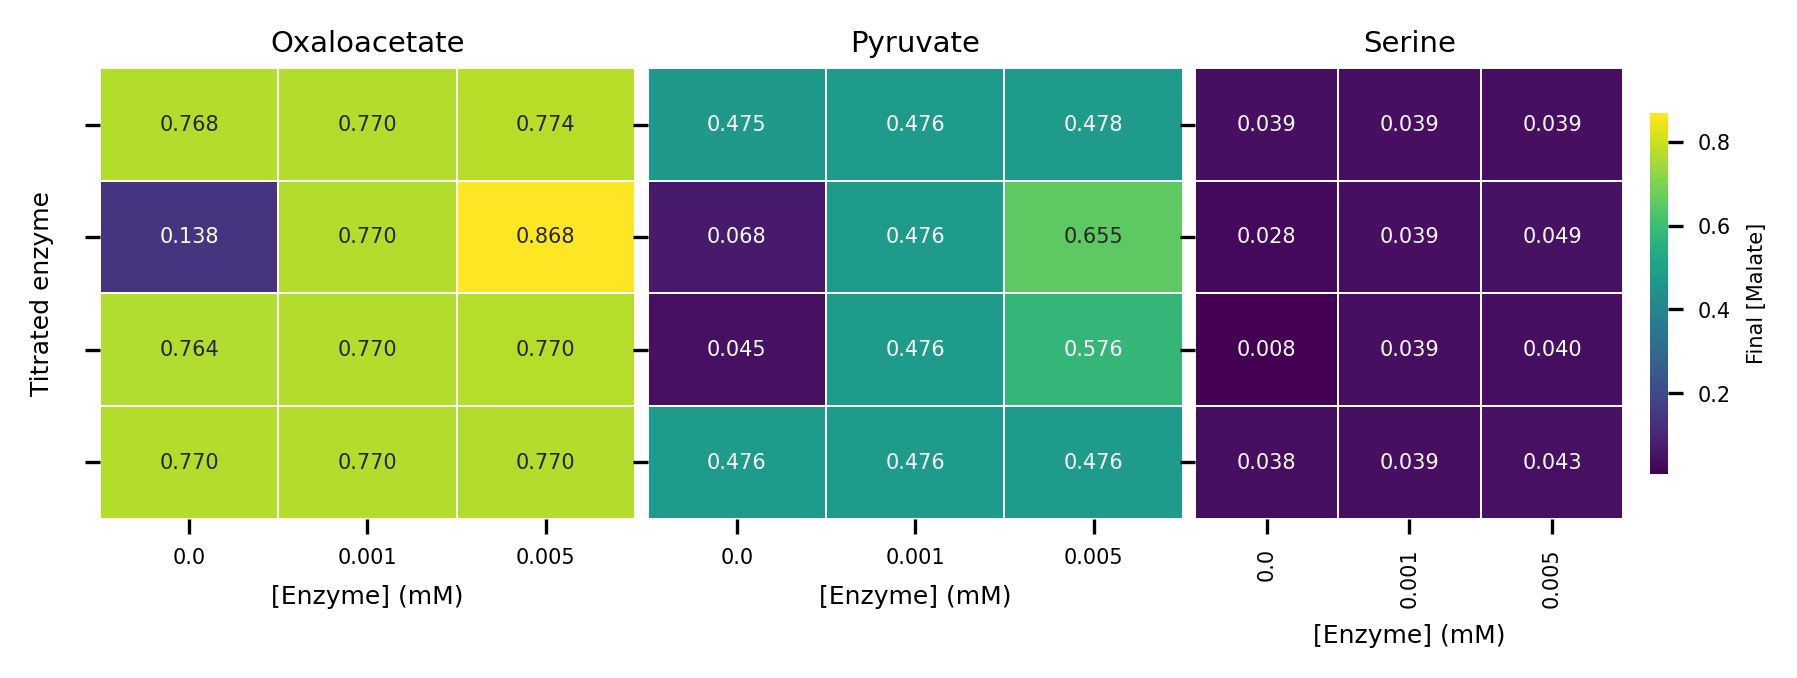

In [ ]:
# --- Combine results into subplots with shared color scale ---
fig, axes = plt.subplots(1, 3, figsize=(6, 2.2), sharey=True, dpi=300)

datasets = [
    ("Oxaloacetate", oaa_results),
    ("Pyruvate", pyr_results),
    ("Serine", ser_results)
]

enzymes = ['fdh', 'mdh', 'pyc', 'sds']
concs = [0, 0.001, 0.005]

# Compute global vmin/vmax for consistent color scaling
all_values = []
for _, results_dict in datasets:
    for arr in results_dict.values():
        all_values.append(arr[-1][4])  # SMalate final value
vmin = np.min(all_values)
vmax = np.max(all_values)

# --- Font sizes for small figure ---
title_font = 7
label_font = 6
tick_font = 5
annot_font = 5
cbar_font = 5

# Plot each heatmap
for ax, (title, results_dict) in zip(axes, datasets):
    malate_df = pd.DataFrame(index=enzymes, columns=concs, dtype=float)
    for key in results_dict.keys():
        enzyme, conc = key.split('_')
        conc = float(conc)
        malate_df.loc[enzyme, conc] = results_dict[key][-1][4]  # [4] is SMalate
    malate_df = malate_df[sorted(malate_df.columns)]

    sns.heatmap(
        malate_df.astype(float),
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=vmin, vmax=vmax,           # shared color scale
        cbar=(ax == axes[-1]),          # only show colorbar on last subplot
        cbar_kws={'label': 'Final [Malate]', 'shrink': 0.8},
        linewidths=0.4,
        annot_kws={'size': annot_font},
        ax=ax
    )

    ax.set_title(f"{title}", fontsize=title_font, pad=4)
    ax.set_xlabel("[Enzyme] (mM)", fontsize=label_font)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=tick_font)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=tick_font, rotation=0)
    if ax == axes[0]:
        ax.set_ylabel("Titrated enzyme", fontsize=label_font)
    else:
        ax.set_ylabel("")

    if ax == axes[-1]:
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=cbar_font)
        cbar.ax.set_ylabel("Final [Malate]", fontsize=cbar_font, labelpad=4)

plt.tight_layout(pad=0.5, w_pad=0.3)
plt.savefig('Figures/Figure_5C.svg')
plt.show()


## Figure 5D: Substrate titration

In [ ]:
ser_tit_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for conc in [0, 0.01, 0.5, 1, 5, 10, 20, 50, 100, 1000]:
        hEC11719 = 0.001 # fdh
        p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

        eEC11137 = 0.001 # mdh
        p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

        hEC6411 = 0.001 # pyc
        p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

        hEC43117 = 0.001 # sds
        p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        param_values['v38'] = (conc / 0.001 / d) + (preSerine / 0.001 / d)
        # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        ser_tit_results[f"ser_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

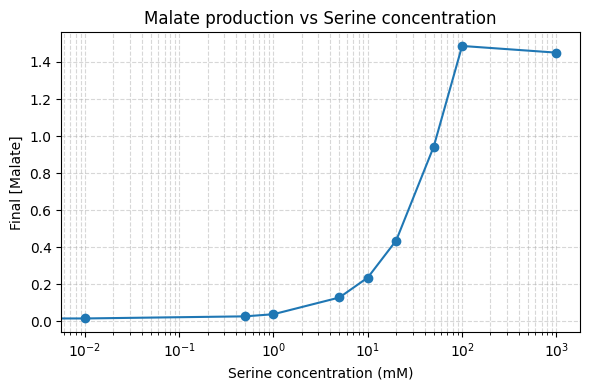

In [ ]:
# Extract concentrations and final malate values
concs = []
final_malate = []

for key, data in ser_tit_results.items():
    # Extract the numeric concentration from key, e.g. 'ser_0.001' → 0.001
    conc = float(key.split('_')[1])
    concs.append(conc)
    
    # Final malate value = last row, column index 4
    final_malate.append(data[-1][4])

# Sort by concentration (in case dict order isn’t sorted)
concs, final_malate = zip(*sorted(zip(concs, final_malate)))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(concs, final_malate, marker='o', linestyle='-')
plt.xscale('log')  # use log scale for enzyme titration
plt.xlabel('Serine concentration (mM)')
plt.ylabel('Final [Malate]')
plt.title('Malate production vs Serine concentration')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
pyr_tit_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for conc in [0, 0.01, 0.5, 1, 5, 10, 20, 50, 100, 1000]:
        hEC11719 = 0.001 # fdh
        p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

        eEC11137 = 0.001 # mdh
        p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

        hEC6411 = 0.001 # pyc
        p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

        hEC43117 = 0.001 # sds
        p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        param_values['v53'] = (conc / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        # param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
        # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        pyr_tit_results[f"pyr_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

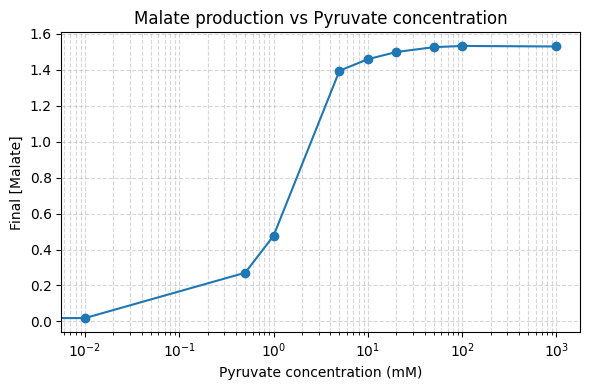

In [ ]:
# Extract concentrations and final malate values
concs = []
final_malate = []

for key, data in pyr_tit_results.items():
    # Extract the numeric concentration from key, e.g. 'ser_0.001' → 0.001
    conc = float(key.split('_')[1])
    concs.append(conc)
    
    # Final malate value = last row, column index 4
    final_malate.append(data[-1][4])

# Sort by concentration (in case dict order isn’t sorted)
concs, final_malate = zip(*sorted(zip(concs, final_malate)))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(concs, final_malate, marker='o', linestyle='-')
plt.xscale('log')  # use log scale for enzyme titration
plt.xlabel('Pyruvate concentration (mM)')
plt.ylabel('Final [Malate]')
plt.title('Malate production vs Pyruvate concentration')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
oaa_tit_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1/200
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for conc in [0, 0.01, 0.5, 1, 5, 10, 20, 50, 100, 1000]:
        hEC11719 = 0.001 # fdh
        p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

        eEC11137 = 0.001 # mdh
        p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

        hEC6411 = 0.001 # pyc
        p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

        hEC43117 = 0.001 # sds
        p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

        param_values['v73'] = 0
        param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
        param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
        # param_values['v53'] = (conc / 0.001 / d) + (prePyruvate / 0.001 / d)
        param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
        param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
        param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
        param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
        # param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
        param_values['v50'] = (conc / 0.001 / d) + (preOxaloacetate / 0.001 / d)

        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 17, 49, 51, 53],
            [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
        )

        rfit.reset()

        try:
            results = rfit.simulate(0, 4*60*60, selections=['time', 'L_Serine', 'Pyruvate', 'Oxaloacetate', 'SMalate', 'Formate', 'NAD', 'NADH'])
        except RuntimeError:
            print('Cannot simulate')

        rfit.resetToOrigin()

        # Store formate vs. time
        oaa_tit_results[f"oaa_{conc}"] = np.array(results)[:, [0, 1, 2, 3, 4, 5, 6, 7]]

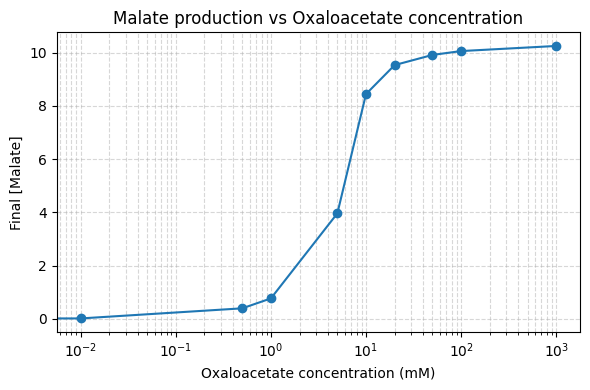

In [ ]:
# Extract concentrations and final malate values
concs = []
final_malate = []

for key, data in oaa_tit_results.items():
    # Extract the numeric concentration from key, e.g. 'ser_0.001' → 0.001
    conc = float(key.split('_')[1])
    concs.append(conc)
    
    # Final malate value = last row, column index 4
    final_malate.append(data[-1][4])

# Sort by concentration (in case dict order isn’t sorted)
concs, final_malate = zip(*sorted(zip(concs, final_malate)))

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(concs, final_malate, marker='o', linestyle='-')
plt.xscale('log')  # use log scale for enzyme titration
plt.xlabel('Oxaloacetate concentration (mM)')
plt.ylabel('Final [Malate]')
plt.title('Malate production vs Oxaloacetate concentration')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

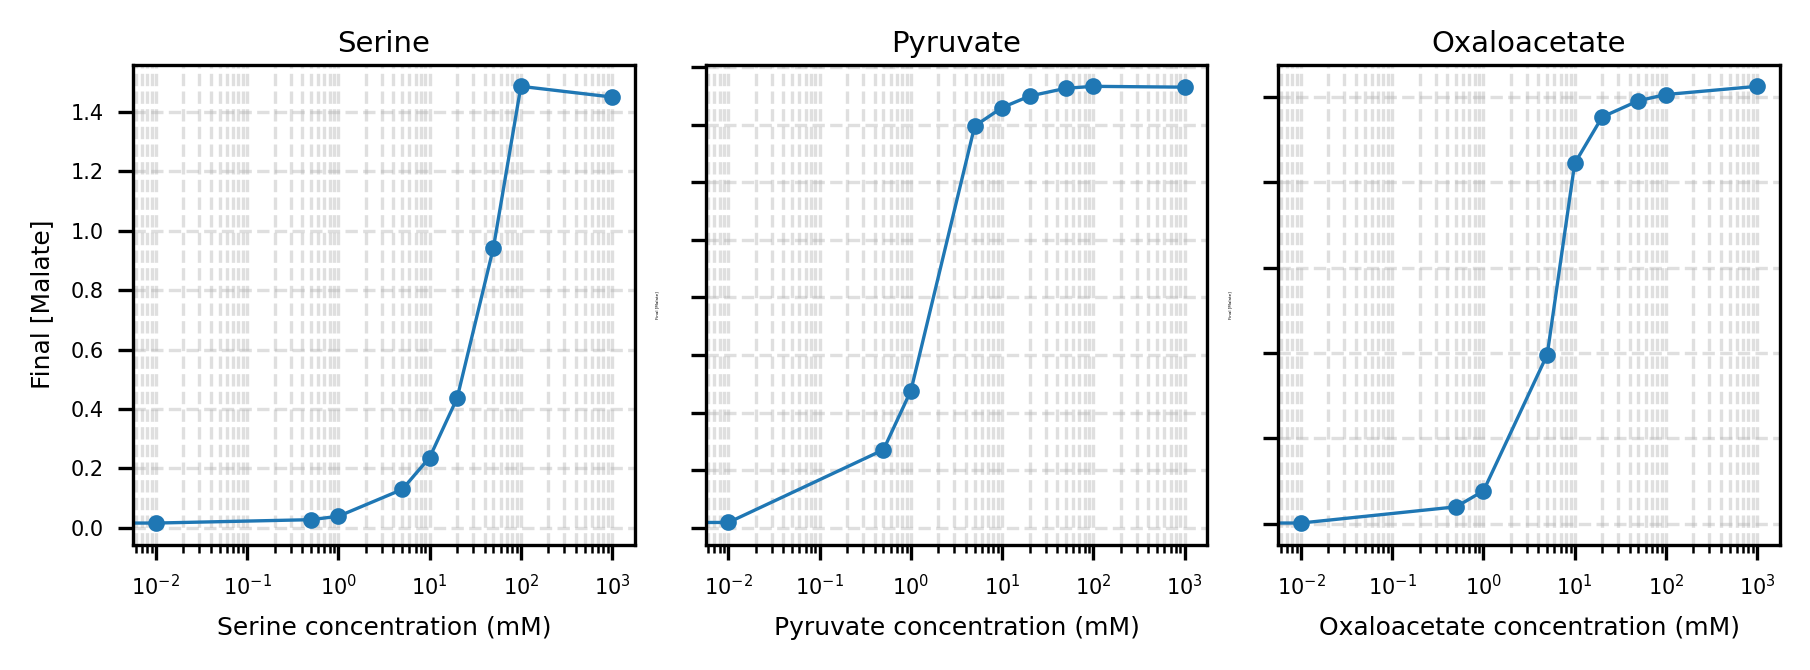

In [ ]:
# --- Prepare data ---
datasets = [
    ("Serine", ser_tit_results, "Serine concentration (mM)"),
    ("Pyruvate", pyr_tit_results, "Pyruvate concentration (mM)"),
    ("Oxaloacetate", oaa_tit_results, "Oxaloacetate concentration (mM)")
]

# --- Small, publication-quality figure ---
fig, axes = plt.subplots(1, 3, figsize=(6, 2.2), dpi=300)

title_font = 7
label_font = 6
tick_font = 5

for ax, (name, results_dict, xlabel) in zip(axes, datasets):
    concs = []
    final_malate = []

    # Extract data
    for key, data in results_dict.items():
        conc = float(key.split('_')[1])
        concs.append(conc)
        final_malate.append(data[-1][4])  # SMalate final value

    # Sort values by concentration
    concs, final_malate = zip(*sorted(zip(concs, final_malate)))

    # --- Plot ---
    ax.plot(concs, final_malate, marker='o', linestyle='-', linewidth=0.8, markersize=3)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=label_font)
    ax.set_ylabel("Final [Malate]", fontsize=label_font if ax == axes[0] else 0)
    if ax != axes[0]:
        ax.set_yticklabels([])  # hide y tick labels for right panels
    ax.set_title(f"{name}", fontsize=title_font, pad=3)
    ax.tick_params(axis='both', labelsize=tick_font)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout(pad=0.6, w_pad=0.5)
plt.savefig('Fiugres/Figure_5D.svg')
plt.show()


In [ ]:
# --- Yield at EC50 (substrate concentration achieving ~half of max final malate) ---
titration_datasets = {
    "Serine": ser_tit_results,
    "Pyruvate": pyr_tit_results,
    "Oxaloacetate": oaa_tit_results,
}

ec50_yields = {}

for name, results_dict in titration_datasets.items():
    points = []
    for key, data in results_dict.items():
        conc = float(key.split('_')[1])
        if conc == 0:
            continue  # skip zero substrate control
        final_malate = data[-1][4]  # SMalate final value
        points.append((conc, final_malate))

    points.sort()
    max_malate = max(malate for _, malate in points)
    half_max = max_malate / 2

    # closest tested concentration to the half-max response (EC50 proxy)
    ec50_conc, ec50_malate = min(points, key=lambda p: abs(p[1] - half_max))
    ec50_yield = ec50_malate / ec50_conc
    ec50_yields[name] = (ec50_conc, ec50_malate, ec50_yield)

    print(f"{name}: max [Malate] = {max_malate:.6g}, half-max target = {half_max:.6g}")
    for conc, malate in points:
        marker = "  <-- closest to half-max (EC50 proxy)" if conc == ec50_conc else ""
        print(f"  [{name}] = {conc:>8g} mM -> Malate = {malate:.6g}{marker}")
    print(f"  EC50 proxy: {ec50_conc:g} mM {name.lower()} -> yield = {ec50_yield:.6g} (Malate = {ec50_malate:.6g})")

ec50_yields

Serine: max [Malate] = 1.48648, half-max target = 0.74324
  [Serine] =     0.01 mM -> Malate = 0.0161767
  [Serine] =      0.5 mM -> Malate = 0.0275072
  [Serine] =        1 mM -> Malate = 0.0390301
  [Serine] =        5 mM -> Malate = 0.12925
  [Serine] =       10 mM -> Malate = 0.23686
  [Serine] =       20 mM -> Malate = 0.436742
  [Serine] =       50 mM -> Malate = 0.943084  <-- closest to half-max (EC50 proxy)
  [Serine] =      100 mM -> Malate = 1.48648
  [Serine] =     1000 mM -> Malate = 1.45042
  EC50 proxy: 50 mM serine -> yield = 0.0188617 (Malate = 0.943084)
Pyruvate: max [Malate] = 1.53332, half-max target = 0.766661
  [Pyruvate] =     0.01 mM -> Malate = 0.0182641
  [Pyruvate] =      0.5 mM -> Malate = 0.270704
  [Pyruvate] =        1 mM -> Malate = 0.47635  <-- closest to half-max (EC50 proxy)
  [Pyruvate] =        5 mM -> Malate = 1.39544
  [Pyruvate] =       10 mM -> Malate = 1.45963
  [Pyruvate] =       20 mM -> Malate = 1.49957
  [Pyruvate] =       50 mM -> Malate = 

{'Serine': (50.0, 0.9430843613102282, 0.018861687226204564),
 'Pyruvate': (1.0, 0.47635016838104155, 0.47635016838104155),
 'Oxaloacetate': (5.0, 3.964613708275304, 0.7929227416550608)}

## Figure 5E: Effect of dilution on malate and CO2 production

In [ ]:
dil_results = {}
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

d = 1
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

for dilfac in [200, 100, 50, 20, 10]:
    d = 1/dilfac
    hEC11719 = 0.001 # fdh
    p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

    eEC11137 = 0.001 # mdh
    p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

    hEC6411 = 0.001 # pyc
    p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

    hEC43117 = 0.001 # sds
    p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

    param_values['v73'] = 0 / (1e-7) / d
    param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
    param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
    # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
    param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
    param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
    param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
    param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
    param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
    # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 17, 49, 51, 53],
        [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
    )

    rfit.reset()

    try:
        results = rfit.simulate(0, 4*60*60, selections=['time','SMalate', 'CO2'])
    except RuntimeError:
        print('Cannot simulate')

    rfit.resetToOrigin()

    # Store formate vs. time
    dil_results[f"{d}X dilution"] = np.array(results)[:, [1, 2]]

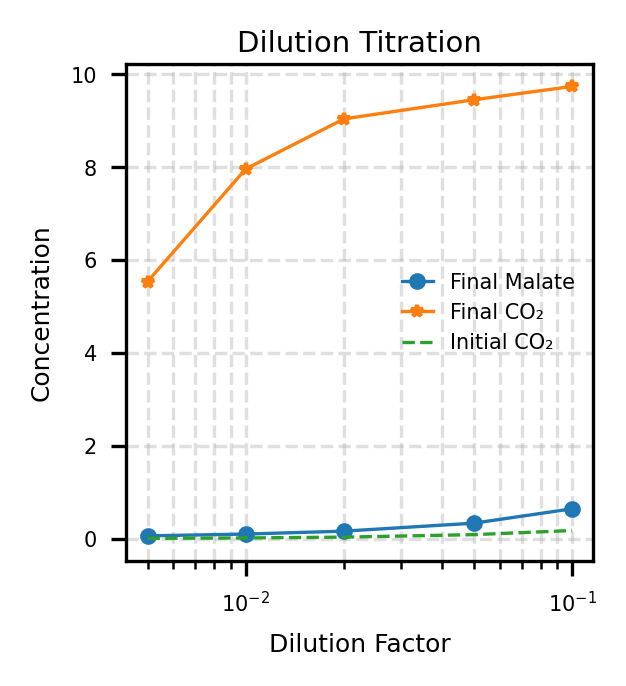

In [ ]:
# --- Extract and sort data ---
concs = []
final_malate = []
final_co2 = []
initial_co2 = []

for key, data in dil_results.items():
    conc = float(key.split('X')[0])
    concs.append(conc)
    final_malate.append(data[-1][0])
    final_co2.append(data[-1][1])
    initial_co2.append(data[0][1])

# Sort once to maintain alignment
sorted_pairs = sorted(zip(concs, final_malate, final_co2, initial_co2))
concs, final_malate, final_co2, initial_co2 = zip(*sorted_pairs)

# --- Fonts (match previous figure) ---
title_font = 7
label_font = 6
tick_font = 5

# --- Figure setup ---
plt.figure(figsize=(2, 2.2), dpi=300)

plt.plot(concs, final_malate, marker='o', linestyle='-', linewidth=0.8, markersize=3, label='Final Malate')
plt.plot(concs, final_co2, marker='*', linestyle='-', linewidth=0.8, markersize=3, label='Final CO₂')
plt.plot(concs, initial_co2, linestyle='--', linewidth=0.8, label='Initial CO₂')

plt.xscale('log')
plt.xlabel('Dilution Factor', fontsize=label_font)
plt.ylabel('Concentration', fontsize=label_font)
plt.title('Dilution Titration', fontsize=title_font, pad=3)
plt.tick_params(axis='both', labelsize=tick_font)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# Compact legend
plt.legend(fontsize=5, loc='best', frameon=False, handlelength=1.5)

plt.tight_layout(pad=0.4)
plt.savefig('Filgures/Figure_5E.svg')
plt.show()

## Figure 5F: Relative malate contributions from TCA and rTCA across dilution factors

In [ ]:
time_points = np.arange(0, 4*60*60 + 1, 60)  # every 1 hour, up to 4 hours
reactions_of_interest = [0, 27, 35, 55, 2, 3, 11, 29, 30, 50]  # indices of reactions
reaction_ids = rfit.getReactionIds()  # get once for naming
allfluxes = []

param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

all_product_amounts = {}

for dilfac in [1, 5, 10, 20, 50, 100, 200]:
    d = 1 / dilfac
        # update parameters (as in your original code)
    hEC11719 = 0.001 # fdh
    p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

    eEC11137 = 0.001 # mdh
    p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

    hEC6411 = 0.001 # pyc
    p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

    hEC43117 = 0.001 # sds
    p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

    param_values['v73'] = 0 / (1e-7) / d
    param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
    param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
    # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
    param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
    param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
    param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
    param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
    param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
    # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 17, 49, 51, 53],
        [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
    )

    rfit.reset()

    times = []
    fluxes = {rid: [] for rid in reactions_of_interest}

    # --- simulate sequentially ---
    for j in range(len(time_points) - 1):
        try:
            rfit.simulate(int(time_points[j]), int(time_points[j + 1]), 2)
            reaction_fluxes = rfit.getReactionRates()
            for rid in reactions_of_interest:
                fluxes[rid].append(reaction_fluxes[rid])

            times.append(time_points[j + 1])

        except RuntimeError:
            print(j)
            rfit.reset()
            rfit.simulate(0, int(time_points[j]))
            rfit.simulate(start=int(time_points[j]), end=int(time_points[j + 1]), steps = 2) #ITS STARTING OVER HERE.. WHY??
            reaction_fluxes = rfit.getReactionRates()
            for rid in reactions_of_interest:
                fluxes[rid].append(reaction_fluxes[rid])
            times.append(time_points[j + 1])


    allfluxes.append(fluxes)

    # --- integrate to get product amounts (mM) ---
    product_amounts = {}
    for rid in reactions_of_interest:
        v = np.array(fluxes[rid])
        # integrate using trapezoidal rule
        product_mM = np.trapz(v, time_points[1:])  # integrate over time in seconds
        product_amounts[rfit.getReactionIds()[rid]] = product_mM

    all_product_amounts[f"{dilfac}X"] = product_amounts

    rfit.resetToOrigin()

114
220
114
195
114
193
114
199
113
203
113
199
113
201


In [ ]:
time_points = np.arange(0, 4*60*60 + 1, 15)  # every 1 hour, up to 4 hours
reactions_of_interest = [19, 24]  # indices of reactions
reaction_ids = rfit.getReactionIds()  # get once for naming
allfluxes = []

param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
prePyruvate = rfit.getValue('Pyruvate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')
preOxaloacetate = rfit.getValue('Oxaloacetate')

all_product_amounts = {}

for dilfac in [10, 20, 50, 100, 200]:
    d = 1 / dilfac
        # update parameters (as in your original code)
    hEC11719 = 0.001 # fdh
    p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

    eEC11137 = 0.001 # mdh
    p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

    hEC6411 = 0.001 # pyc
    p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

    hEC43117 = 0.001 # sds
    p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

    param_values['v73'] = 0 / (1e-7) / d
    param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
    param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
    # param_values['v53'] = (1 / 0.001 / d) + (prePyruvate / 0.001 / d)
    param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
    param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
    param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
    param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
    param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)
    # param_values['v50'] = (1 / 0.001 / d) + (preOxaloacetate / 0.001 / d)

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 17, 49, 51, 53],
        [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
    )

    rfit.reset()

    times = []
    fluxes = {rid: [] for rid in reactions_of_interest}

    # --- simulate sequentially ---
    for j in range(len(time_points) - 1):
        try:
            rfit.simulate(int(time_points[j]), int(time_points[j + 1]), 2)
            reaction_fluxes = rfit.getReactionRates()
            for rid in reactions_of_interest:
                fluxes[rid].append(-(reaction_fluxes[rid]))

            times.append(time_points[j + 1])

        except RuntimeError:
            print(j)
            rfit.reset()
            rfit.simulate(0, int(time_points[j]))
            rfit.simulate(start=int(time_points[j]), end=int(time_points[j + 1]), steps = 2)
            reaction_fluxes = rfit.getReactionRates()
            for rid in reactions_of_interest:
                fluxes[rid].append(-(reaction_fluxes[rid]))
            times.append(time_points[j + 1])


    allfluxes.append(fluxes)

    # --- integrate to get product amounts (mM) ---
    product_amounts = {}
    for rid in reactions_of_interest:
        v = np.array(fluxes[rid])
        # integrate using trapezoidal rule
        product_mM = np.trapz(v, time_points[1:])  # integrate over time in seconds
        product_amounts[rfit.getReactionIds()[rid]] = product_mM

    all_product_amounts[f"{dilfac}X"] = product_amounts

    rfit.resetToOrigin()

456
771
456
782
455
801
455
812
454
808


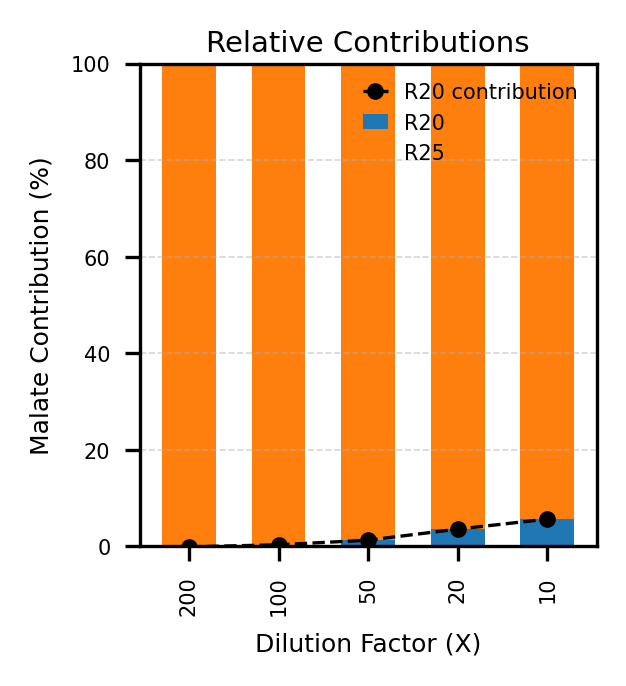

In [ ]:
# --- Convert to DataFrame ---
df = pd.DataFrame(all_product_amounts).T
df.index = df.index.str.replace('X', '').astype(float)

# --- Select reactions of interest ---
reactions = ['R20', 'R25']
df = df[reactions]

# --- Filter out 1X and 5X ---
df = df.loc[~df.index.isin([1, 5])]

# --- Normalize to percentage contributions ---
df_pct = df.div(df.sum(axis=1), axis=0) * 100

# --- Reverse dilution order ---
df_pct = df_pct.sort_index(ascending=False)

# --- Fonts (match previous figures) ---
title_font = 7
label_font = 6
tick_font = 5

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(2, 2.2), dpi=300)

# Stacked bar chart (percentages)
colors = ['#1f77b4', '#ff7f0e']
df_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.6, legend=False)

# Add line for R20 contribution
ax.plot(range(len(df_pct.index)), df_pct['R20'],
        color='black', marker='o', linestyle='--', linewidth=0.8,
        markersize=3, label='R20 contribution')

# Labels and styling
ax.set_xlabel('Dilution Factor (X)', fontsize=label_font)
ax.set_ylabel('Malate Contribution (%)', fontsize=label_font)
ax.set_title('Relative Contributions', fontsize=title_font, pad=3)
ax.set_ylim(0, 100)
ax.set_xticks(range(len(df_pct.index)))
ax.set_xticklabels(df_pct.index.astype(int), fontsize=tick_font)
ax.tick_params(axis='y', labelsize=tick_font)

# Compact legend
ax.legend(fontsize=5, loc='upper right', frameon=False, handlelength=1.2)

ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)

plt.tight_layout(pad=0.4)
plt.savefig('Figures/Figure_5F.svg')
plt.show()


## Figure 5G: MCA-inspired sensitivity coefficient analysis

In [ ]:
path = "/iMC057.txt"

with open(path, "r") as f:
    text = f.read()

# Updated regex pattern:
pattern = re.compile(
    r"(?P<species>\S+)\s*=\s*(?P<v>v\d+)\*(?P<val>[0-9.eE+-]+)\*dilution_factor;"
)

lookup = {}
for match in pattern.finditer(text):
    species = match.group("species")
    v = match.group("v")
    val_str = match.group("val")

    # Safely convert to float (handles "1e-7" and "0.001")
    try:
        val = float(val_str)
    except ValueError:
        val = None  # or handle differently if needed

    lookup[species] = {"v": v, "val": val}

In [ ]:
with open('filtering_parameter_sets/final_params.pkl', 'rb') as file:
    trainparams = pickle.load(file)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

In [ ]:
# Dilution factors we want to test
d = 1/200

In [ ]:
ids = rfit.getIds()
species = ids[50:121]

In [ ]:
param_values = param_values_dict.copy()

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

# still going to introduce heterologous pathway
hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.001 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.001 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))

param_values = param_values_dict.copy()

param_values['v73'] = 10 / (1e-7) / d
param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 17, 49, 51, 53],
    [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
)

rfit.reset()

try:
    results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate'])
except RuntimeError:
    print('Cannot simulate')

rfit.resetToOrigin()

print(results[-1][1])

0.05549432819948107


In [ ]:
species_inits = {}
param_values = param_values_dict.copy()
metaboliteIncrease = []

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

# still going to introduce heterologous pathway
hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.001 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.001 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


for s in species:
    species_inits[f'pre_{s}'] = rfit.getValue(s)
    v = lookup[s]["v"]
    val = lookup[s]["val"]

    print(s)
    print(rfit.getValue(s))

    param_values = param_values_dict.copy()

    param_values['v73'] = 10 / (1e-7) / d
    param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
    param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
    param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
    param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
    param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
    param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
    param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

    param_values[v] = (species_inits[f'pre_{s}']*100 / val / d)

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 17, 49, 51, 53],
        [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
    )

    rfit.reset()

    print(rfit.getValue(s))

    try:
        results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate'])
    except RuntimeError:
        print('Cannot simulate')

    rfit.resetToOrigin()

    # Store formate vs. time
    metaboliteIncrease.append(results[-1][1])  # time + Malate

_3E_3_Enoyl_CoA
1.7473540999784268e-05
0.0017473540999784268
_3R_3_Hydroxyacyl_acyl_carrier_protein
0.001
0.1
_3S_3_Hydroxyacyl_CoA
0.001
0.1
ADP
0.1
10.0
AMP
10.0
1000.0
ATP
1.5
150.0
Acetate
69.3
6930.0
Acetoacetyl_acp
0.001
0.1
AcetylCoA
0.61
61.0
Acetyl_phosphate
1.1
110.0
Acyl_acyl_carrier_protein
0.001
0.1
Acyl_carrier_protein
0.001
0.1
Ammonia
15.0
1500.0
CO2
0.0184
1.84
Citrate
2.0
200.0
CoA
4.4
440.0
D_Erythrose_4_phosphate
0.001
0.1
D_Fructose_1_6_bisphosphate
15.0
1500.0
D_Fructose_6_phosphate
3.8
380.0
D_Glucono_1_5_lactone_6_phosphate
0.001
0.1
D_Glucose_1_phosphate
0.001
0.1
DGlucose6phosphate
5.0
500.0
D_Glyceraldehyde_3_phosphate
0.001
0.1
D_ribose_5_phosphate
0.001
0.1
D_Ribulose_5_phosphate
0.5
50.0
D_Xylulose_5_phosphate
0.5
50.0
Diphosphate
1.0
100.0
Fumarate
0.12
12.0
Glycerone_phosphate
0.001
0.1
Glycine
0.001
0.1
Glyoxylate
0.001
0.1
H2O
55000.0
5500000.0
HCO3
0.015
1.5
Hydroquinone
1.0
100.0
Isocitrate
0.001
0.1
L_Serine
0.001
0.1
LongchainacylCoA
0.001
0.1
Long

In [ ]:
species_inits = {}
param_values = param_values_dict.copy()
metaboliteDecrease = []

# Test: No enzymes or HCT, but all cofactors
rfit.model.setGlobalParameterValues(
    [*param_labels_dict.values(), 2, 49, 51, 53],
    [*param_values.values(), d, 0, 0, 0]
)
rfit.reset()

rel0 = rfit.rel0
rel1 = rfit.rel1
rel2 = rfit.rel2
rel3 = rfit.rel3

preNADH = rfit.getValue('NADH')
preFormate = rfit.getValue('Formate')
preATP = rfit.getValue('ATP')
preAcCoA = rfit.getValue('AcetylCoA')
preHCO3 = rfit.getValue('HCO3')
preAcetate = rfit.getValue('Acetate')
preMdh = rfit.getValue('eEC11137')
preSerine = rfit.getValue('L_Serine')

# still going to introduce heterologous pathway
hEC11719 = 0.001 # fdh
p_hEC11719 = (hEC11719 / (0.01 * d * rel2))

eEC11137 = 0.001 # mdh
p_eEC11137 = (eEC11137 / (0.012601796 * d * rel0)) + (preMdh / (0.012601796 * d * rel0))

hEC6411 = 0.001 # pyc
p_hEC6411 = (hEC6411 / (0.01 * d * rel1))

hEC43117 = 0.001 # sds
p_hEC43117 = (hEC43117 / (0.01 * d * rel3))


for s in species:
    species_inits[f'pre_{s}'] = rfit.getValue(s)
    v = lookup[s]["v"]
    val = lookup[s]["val"]

    print(s)
    print(rfit.getValue(s))

    param_values = param_values_dict.copy()

    param_values['v73'] = 10 / (1e-7) / d
    param_values['v44'] = (1 / 0.083 / d) + (preNADH / 0.083 / d)
    param_values['v74'] = (10 / 0.001 / d) + (preFormate / 0.001 / d)
    param_values['v6'] = (1 / 1.5 / d) + (preATP / 1.5 / d)
    param_values['v10'] = (1 / 0.61 / d) + (preAcCoA / 0.61 / d)
    param_values['v35'] = (10 / 0.015 / d) + (preHCO3 / 0.015 / d)
    param_values['v7'] = (2 / 69.3 / d) + (preAcetate / 69.3 / d)
    param_values['v38'] = (1 / 0.001 / d) + (preSerine / 0.001 / d)

    param_values[v] = (species_inits[f'pre_{s}'] / 100 / val / d)

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 17, 49, 51, 53],
        [*param_values.values(), d, p_eEC11137, p_hEC6411, p_hEC11719, p_hEC43117]
    )

    rfit.reset()

    print(rfit.getValue(s))

    try:
        results = rfit.simulate(0, 4*60*60, selections=['time', 'SMalate'])
    except RuntimeError:
        print('Cannot simulate')

    rfit.resetToOrigin()

    # Store formate vs. time
    metaboliteDecrease.append(results[-1][1])  # time + Malate

_3E_3_Enoyl_CoA
1.7473540999784268e-05
1.7473540999784265e-07
_3R_3_Hydroxyacyl_acyl_carrier_protein
0.001
1e-05
_3S_3_Hydroxyacyl_CoA
0.001
1e-05
ADP
0.1
0.001
AMP
10.0
0.1
ATP
1.5
0.015
Acetate
69.3
0.693
Acetoacetyl_acp
0.001
1e-05
AcetylCoA
0.61
0.0061
Acetyl_phosphate
1.1
0.011000000000000001
Acyl_acyl_carrier_protein
0.001
1e-05
Acyl_carrier_protein
0.001
1e-05
Ammonia
15.0
0.15
CO2
0.0184
0.000184
Citrate
2.0
0.02
CoA
4.4
0.044000000000000004
D_Erythrose_4_phosphate
0.001
1e-05
D_Fructose_1_6_bisphosphate
15.0
0.15
D_Fructose_6_phosphate
3.8
0.038
D_Glucono_1_5_lactone_6_phosphate
0.001
1e-05
D_Glucose_1_phosphate
0.001
1e-05
DGlucose6phosphate
5.0
0.05
D_Glyceraldehyde_3_phosphate
0.001
1e-05
D_ribose_5_phosphate
0.001
1e-05
D_Ribulose_5_phosphate
0.5
0.005
D_Xylulose_5_phosphate
0.5
0.005
Diphosphate
1.0
0.01
Fumarate
0.12
0.0012
Glycerone_phosphate
0.001
1e-05
Glycine
0.001
1e-05
Glyoxylate
0.001
1e-05
H2O
55000.0
550.0
HCO3
0.015
0.00015
Hydroquinone
1.0
0.01
Isocitrate
0.00

In [ ]:
# Compute control coefficients
C = (np.log(metaboliteIncrease) - np.log(metaboliteDecrease)) / np.log(1e4)

# Make a tidy DataFrame
df = pd.DataFrame({
    "species": species,
    "malate_up": metaboliteIncrease,
    "malate_down": metaboliteDecrease,
    "control_coeff": C
})

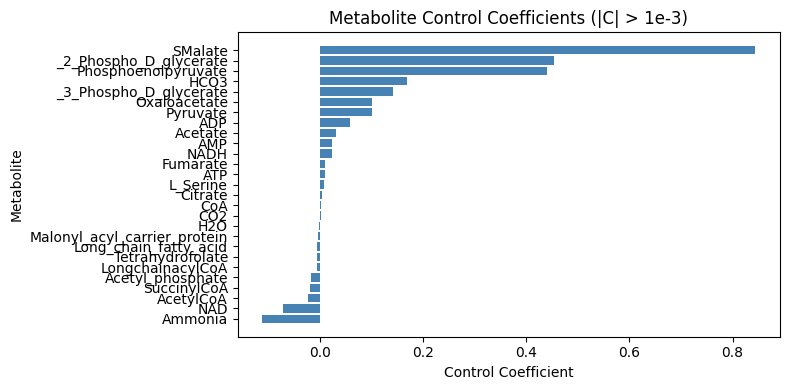

In [ ]:
# Filter rows where |control_coeff| > 1e-3
filtered_df = df[np.abs(df["control_coeff"]) > 1e-3]

# (Optional) sort by magnitude for a cleaner plot
filtered_df = filtered_df.reindex(filtered_df["control_coeff"].sort_values(ascending=True).index)

# Plot
plt.figure(figsize=(8,4))
plt.barh(filtered_df["species"], filtered_df["control_coeff"], color="steelblue")
plt.ylabel("Metabolite")
plt.xlabel('Control Coefficient')
plt.title("Metabolite Control Coefficients (|C| > 1e-3)")
plt.tight_layout()
plt.show()

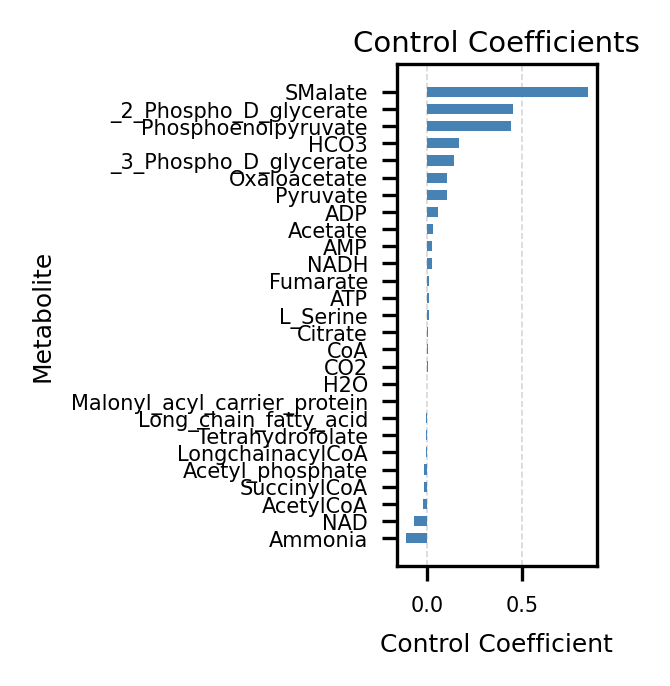

In [ ]:
# --- Filter and sort ---
filtered_df = df[np.abs(df["control_coeff"]) > 1e-3]
filtered_df = filtered_df.reindex(filtered_df["control_coeff"].sort_values(ascending=True).index)

# --- Fonts (match previous figures) ---
title_font = 7
label_font = 6
tick_font = 5

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(2, 2.2), dpi=300)

ax.barh(filtered_df["species"], filtered_df["control_coeff"],
        color="steelblue", edgecolor='none', height=0.6)

# Labels and title
ax.set_xlabel('Control Coefficient', fontsize=label_font)
ax.set_ylabel('Metabolite', fontsize=label_font)
ax.set_title('Control Coefficients', fontsize=title_font, pad=3)

# Ticks and grid
ax.tick_params(axis='both', labelsize=tick_font)
ax.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout(pad=0.4)
plt.savefig('Figures/Figure_5G.svg')
plt.show()
